In [3]:
import numpy as np
from sklearn.cluster import KMeans

In [ ]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=120, centers=3, n_features=2, random_state=42)

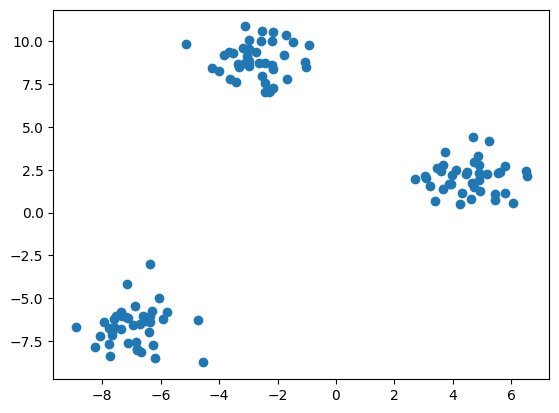

In [7]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])

In [21]:
#tree structure

class HKMnode:
    def __init__(self, centroids=None, children=None, leaf=True, points=None):
        self.centroids = centroids
        self.children = children or []
        self.points = points
        self.leaf = leaf

In [22]:
#indexing

def hierarchicalIndexing(data, branching_factor, level, max_level, min_points):
    if data.shape[0] < min_points or level == max_level:
        leaf = HKMnode(points = data, leaf=True)
        return leaf
    
    kmeans = KMeans(n_clusters=branching_factor, random_state=42).fit(data)

    centroids = kmeans.cluster_centers_
    labels = kmeans.labels_
    
    node = HKMnode(centroids=centroids, leaf=False)

    for i in range(branching_factor):
        points_in_cluster = data[labels == i]
        child = hierarchicalIndexing(
            points_in_cluster,
            branching_factor,
            level + 1,
            max_level,
            min_points
        )
        node.children.append(child)
    
    return node


    

In [24]:
root = hierarchicalIndexing(X, 3, 0, 5, 3)

In [26]:
def validate_hkm_tree(node, level=0):
    indent = "  " * level

    # Leaf node checks
    if node.leaf:
        if node.points is None:
            print(f"{indent}❌ Leaf at level {level} has no points")
            return False
        print(f"{indent}✔ Leaf at level {level} with {node.points.shape[0]} points")
        return True

    # Internal node checks
    if node.centroids is None:
        print(f"{indent}❌ Internal node at level {level} has no centroids")
        return False

    print(f"{indent}✔ Internal node at level {level} with {len(node.centroids)} centroids")

    # Check children count
    if len(node.children) != len(node.centroids):
        print(f"{indent}❌ Children count ({len(node.children)}) "
              f"does not match centroid count ({len(node.centroids)})")
        return False

    # Recurse into children
    ok = True
    for child in node.children:
        ok = validate_hkm_tree(child, level + 1) and ok

    return ok


In [27]:
import numpy as np

def collect_leaf_points(node):
    if node.leaf:
        return node.points
    pts = []
    for child in node.children:
        pts.append(collect_leaf_points(child))
    return np.vstack(pts)


In [28]:
leaf_points = collect_leaf_points(root)

print("Original:", X.shape[0])
print("Collected:", leaf_points.shape[0])
print("Match:", X.shape[0] == leaf_points.shape[0])


Original: 120
Collected: 120
Match: True


In [29]:
validate_hkm_tree(root)


✔ Internal node at level 0 with 3 centroids
  ✔ Internal node at level 1 with 3 centroids
    ✔ Internal node at level 2 with 3 centroids
      ✔ Internal node at level 3 with 3 centroids
        ✔ Leaf at level 4 with 1 points
        ✔ Leaf at level 4 with 2 points
        ✔ Leaf at level 4 with 1 points
      ✔ Internal node at level 3 with 3 centroids
        ✔ Leaf at level 4 with 1 points
        ✔ Internal node at level 4 with 3 centroids
          ✔ Leaf at level 5 with 1 points
          ✔ Leaf at level 5 with 1 points
          ✔ Leaf at level 5 with 1 points
        ✔ Leaf at level 4 with 1 points
      ✔ Leaf at level 3 with 2 points
    ✔ Internal node at level 2 with 3 centroids
      ✔ Leaf at level 3 with 1 points
      ✔ Internal node at level 3 with 3 centroids
        ✔ Internal node at level 4 with 3 centroids
          ✔ Leaf at level 5 with 1 points
          ✔ Leaf at level 5 with 1 points
          ✔ Leaf at level 5 with 1 points
        ✔ Leaf at level 4 with 2

True